# Pairs Trading — EDA (After Outlier Handling)

**Input:** `data/interim/prices_clean.csv`  

Re-runs plots affected by outlier handling (to a not-so-significant extent):
- Plot 1: Return Distribution
- Plot 2: Volatility Regimes
- Plot 3: Pairwise Correlation Distribution
- Plot 4: Correlation Heatmap (Top 50)

| # | Plot |
|---|------|
| 1 | Return Distribution |
| 2 | Volatility Regimes |
| 3 | Pairwise Correlation Distribution |
| 4 | Correlation Heatmap (Top 50) |
| 5 | Return ACF |
| + | ADF Stationarity Check |

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.stattools import acf as sm_acf, adfuller
import statsmodels.api as sm

sns.set_theme(style="whitegrid", font_scale=1.05)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Notebook sits at project root (same level as data/, src/, outputs/)
PROJECT_ROOT = Path('.').resolve()
DATA_PATH    = PROJECT_ROOT / 'data' / 'interim' / 'prices_clean.csv'

# ── Constants ─────────────────────────────────────────────────────────────────
MIN_TRADING_DAYS = 252
MAX_LAGS         = 20

print(f'Project root : {PROJECT_ROOT}')
print(f'Data path    : {DATA_PATH}')
print(f'Data exists  : {DATA_PATH.exists()}')

Project root : C:\Users\cathe\Documents\NUS folder\Pairs-Trading
Data path    : C:\Users\cathe\Documents\NUS folder\Pairs-Trading\data\interim\prices_clean.csv
Data exists  : True


## Load & prep

In [2]:
# prices_clean.csv is long-format: Date, Open, High, Low, Close, Volume, Ticker
all_stocks = pd.read_csv(DATA_PATH, parse_dates=['Date'])
all_stocks = all_stocks.sort_values(['Ticker', 'Date']).reset_index(drop=True)

print(f'Rows    : {len(all_stocks):,}')
print(f'Tickers : {all_stocks["Ticker"].nunique():,}')
print(f'Dates   : {all_stocks["Date"].min().date()} to {all_stocks["Date"].max().date()}')
all_stocks.head()

Rows    : 1,739,361
Tickers : 1,000
Dates   : 2010-01-04 to 2017-11-10


,Date,Open,High,Low,Close,Volume,Ticker
0,2010-01-04,21.245,21.350,21.014,21.128,4043084,a
1,2010-01-05,21.067,21.075,20.764,20.899,4435651,a
2,2010-01-06,20.899,20.927,20.764,20.825,3437283,a
3,2010-01-07,20.777,20.805,20.589,20.798,3279988,a
4,2010-01-08,20.683,20.825,20.520,20.791,3956596,a


In [3]:
# Compute daily return, log price, and year columns
all_stocks['Return']    = all_stocks.groupby('Ticker')['Close'].pct_change()
all_stocks['Log_Price'] = np.log(all_stocks['Close'])
all_stocks['Year']      = all_stocks['Date'].dt.year

tickers  = all_stocks['Ticker'].unique().tolist()
n_stocks = len(tickers)

# Build return pivot (dates x tickers) — reused across all plots
print('Building return pivot matrix ...')
pivot_returns = all_stocks.pivot_table(index='Date', columns='Ticker', values='Return')

# Keep only stocks with >= MIN_TRADING_DAYS non-null returns
pivot_filtered = pivot_returns.dropna(thresh=MIN_TRADING_DAYS, axis=1)
n_filtered     = pivot_filtered.shape[1]

print(f'  {n_filtered} / {n_stocks} stocks have >= {MIN_TRADING_DAYS} trading days.')


Building return pivot matrix ...
  964 / 1000 stocks have >= 252 trading days.


---
## Plot 1 — Return Distribution (after cleaning)
Compare skewness and kurtosis to the before-cleaning values.

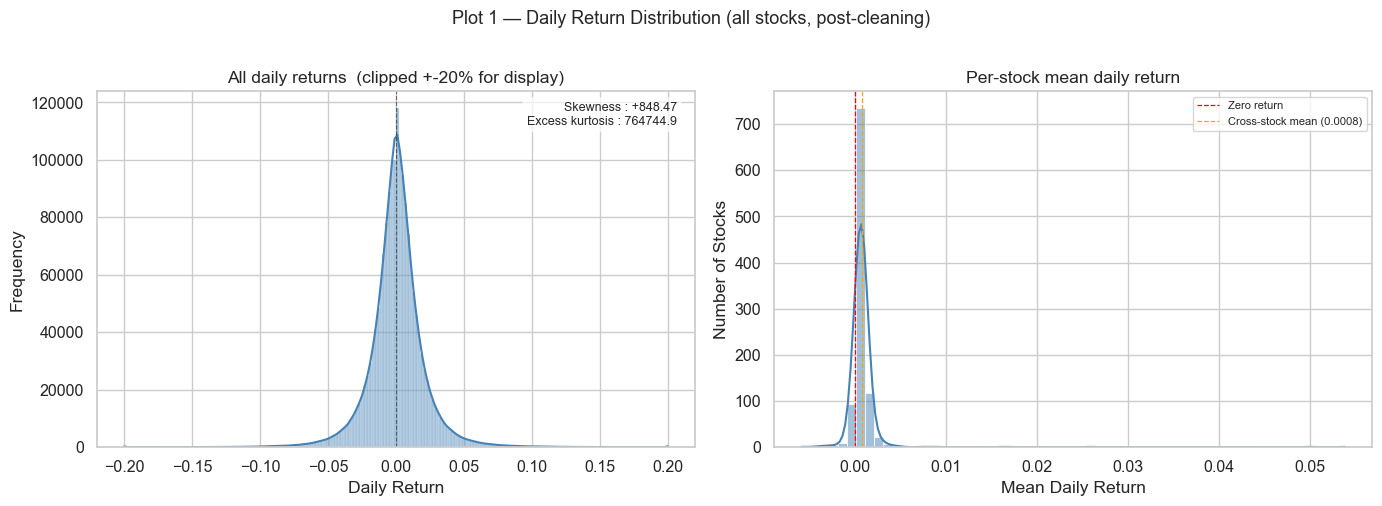

In [4]:
returns_all    = all_stocks['Return'].replace([np.inf, -np.inf], np.nan).dropna()
per_stock_mean = (
    all_stocks.groupby('Ticker')['Return']
    .mean()
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Plot 1 — Daily Return Distribution (all stocks, post-cleaning)', fontsize=13, y=1.01)

# Left: all returns clipped at +-20% so extremes don't collapse the histogram
axes[0].set_title('All daily returns  (clipped +-20% for display)')
sns.histplot(returns_all.clip(-0.2, 0.2), bins=200, kde=True, color='steelblue', ax=axes[0])
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
axes[0].set_xlabel('Daily Return')
axes[0].set_ylabel('Frequency')

skew = float(returns_all.skew())
kurt = float(returns_all.kurt())
axes[0].text(
    0.97, 0.97,
    f'Skewness : {skew:+.2f}\nExcess kurtosis : {kurt:.1f}',
    transform=axes[0].transAxes, fontsize=9, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7)
)

# Right: per-stock mean daily return
axes[1].set_title('Per-stock mean daily return')
sns.histplot(per_stock_mean, bins=60, kde=True, color='steelblue', ax=axes[1])
axes[1].axvline(0, color='red', linewidth=0.9, linestyle='--', label='Zero return')
axes[1].axvline(
    float(per_stock_mean.mean()), color='orange', linewidth=0.9, linestyle='--',
    label=f'Cross-stock mean ({per_stock_mean.mean():.4f})'
)
axes[1].set_xlabel('Mean Daily Return')
axes[1].set_ylabel('Number of Stocks')
axes[1].legend(fontsize=8)

plt.tight_layout()


---
## Plot 2 — Volatility Regimes (after cleaning)
Spurious spikes from bad data should be gone.

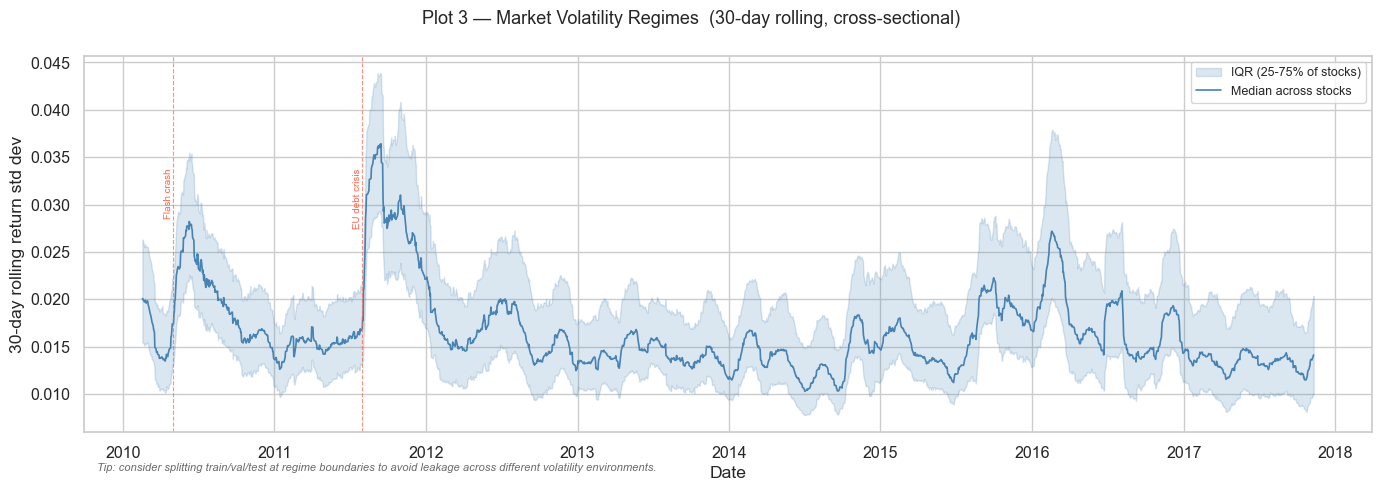

In [5]:
rolling_vol = pivot_filtered.rolling(30).std()
median_vol  = rolling_vol.median(axis=1).dropna()
p25_vol     = rolling_vol.quantile(0.25, axis=1).reindex(median_vol.index)
p75_vol     = rolling_vol.quantile(0.75, axis=1).reindex(median_vol.index)

fig, ax = plt.subplots(figsize=(14, 5))
fig.suptitle('Plot 3 — Market Volatility Regimes  (30-day rolling, cross-sectional)', fontsize=13)

ax.fill_between(median_vol.index, p25_vol, p75_vol,
                alpha=0.2, color='steelblue', label='IQR (25-75% of stocks)')
ax.plot(median_vol.index, median_vol, color='steelblue',
        linewidth=1.2, label='Median across stocks')

regime_events = {
    '2000-03': 'Dot-com peak',
    '2002-10': 'Dot-com trough',
    '2008-09': 'GFC',
    '2010-05': 'Flash crash',
    '2011-08': 'EU debt crisis',
}
for date_str, label in regime_events.items():
    x = pd.Timestamp(date_str)
    if median_vol.index.min() <= x <= median_vol.index.max():
        ax.axvline(x, color='tomato', linewidth=0.8, linestyle='--', alpha=0.7)
        ax.text(x, float(median_vol.max()) * 0.93, label,
                color='tomato', fontsize=7, rotation=90, va='top', ha='right')

ax.set_xlabel('Date')
ax.set_ylabel('30-day rolling return std dev')
ax.legend(fontsize=9)
ax.text(
    0.01, -0.08,
    'Tip: consider splitting train/val/test at regime boundaries '
    'to avoid leakage across different volatility environments.',
    transform=ax.transAxes, fontsize=8, va='top', style='italic', color='dimgray'
)

plt.tight_layout()


---
## Plot 3 — Pairwise Correlation Distribution (after cleaning)
Check whether removing suspicious rows shifts the correlation distribution.

Computing correlation matrix ... (may take ~30 seconds for 1000 stocks)


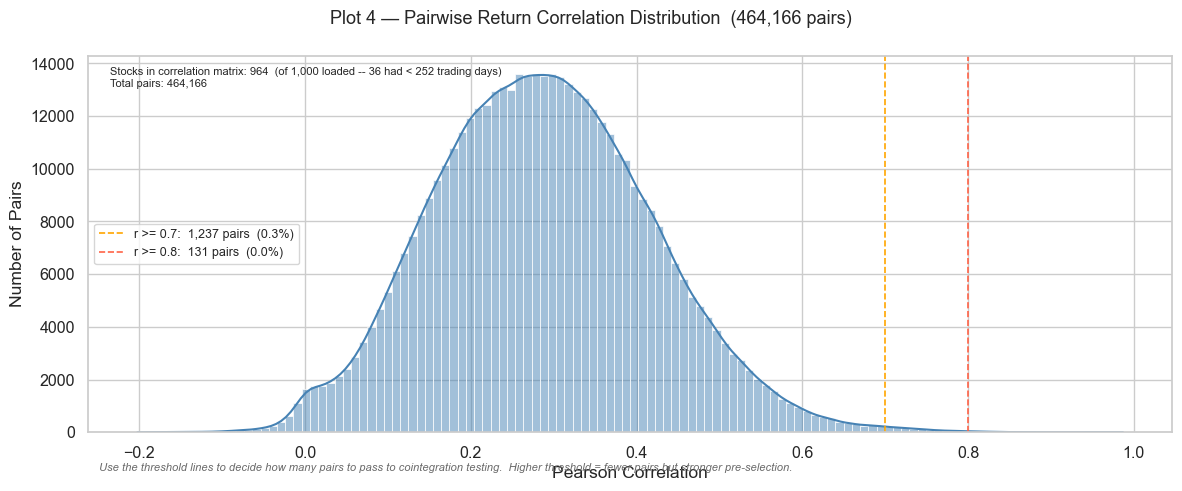

In [6]:
print('Computing correlation matrix ... (may take ~30 seconds for 1000 stocks)')
corr_matrix   = pivot_filtered.corr()
n_corr_stocks = corr_matrix.shape[0]

# Save full matrix for downstream reuse
# corr_matrix.to_csv(OUTPUT_DIR / 'full_correlation_matrix.csv')
# print(f'  Saved: full_correlation_matrix.csv  ({n_corr_stocks}x{n_corr_stocks})')

# Upper triangle only (excludes diagonal and duplicates)
upper_mask = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
all_corrs  = corr_matrix.values[upper_mask]
n_pairs    = len(all_corrs)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(f'Plot 4 — Pairwise Return Correlation Distribution  ({n_pairs:,} pairs)', fontsize=13)

sns.histplot(all_corrs, bins=120, kde=True, color='steelblue', ax=ax)

for threshold, colour in [(0.7, 'orange'), (0.8, 'tomato')]:
    n_above = int((all_corrs >= threshold).sum())
    pct     = 100 * n_above / n_pairs
    ax.axvline(threshold, color=colour, linewidth=1.2, linestyle='--',
               label=f'r >= {threshold}:  {n_above:,} pairs  ({pct:.1f}%)')

ax.set_xlabel('Pearson Correlation')
ax.set_ylabel('Number of Pairs')
ax.legend(fontsize=9)
ax.text(
    0.02, 0.97,
    f'Stocks in correlation matrix: {n_corr_stocks:,}  '
    f'(of {n_stocks:,} loaded -- {n_stocks - n_corr_stocks} had < {MIN_TRADING_DAYS} trading days)\n'
    f'Total pairs: {n_pairs:,}',
    transform=ax.transAxes, fontsize=8, va='top'
)
ax.text(
    0.01, -0.08,
    'Use the threshold lines to decide how many pairs to pass to cointegration testing.  '
    'Higher threshold = fewer pairs but stronger pre-selection.',
    transform=ax.transAxes, fontsize=8, va='top', style='italic', color='dimgray'
)

plt.tight_layout()


---
## Plot 4 — Correlation Heatmap Top 50 (after cleaning)
Check whether block structure changes after removing suspicious rows.

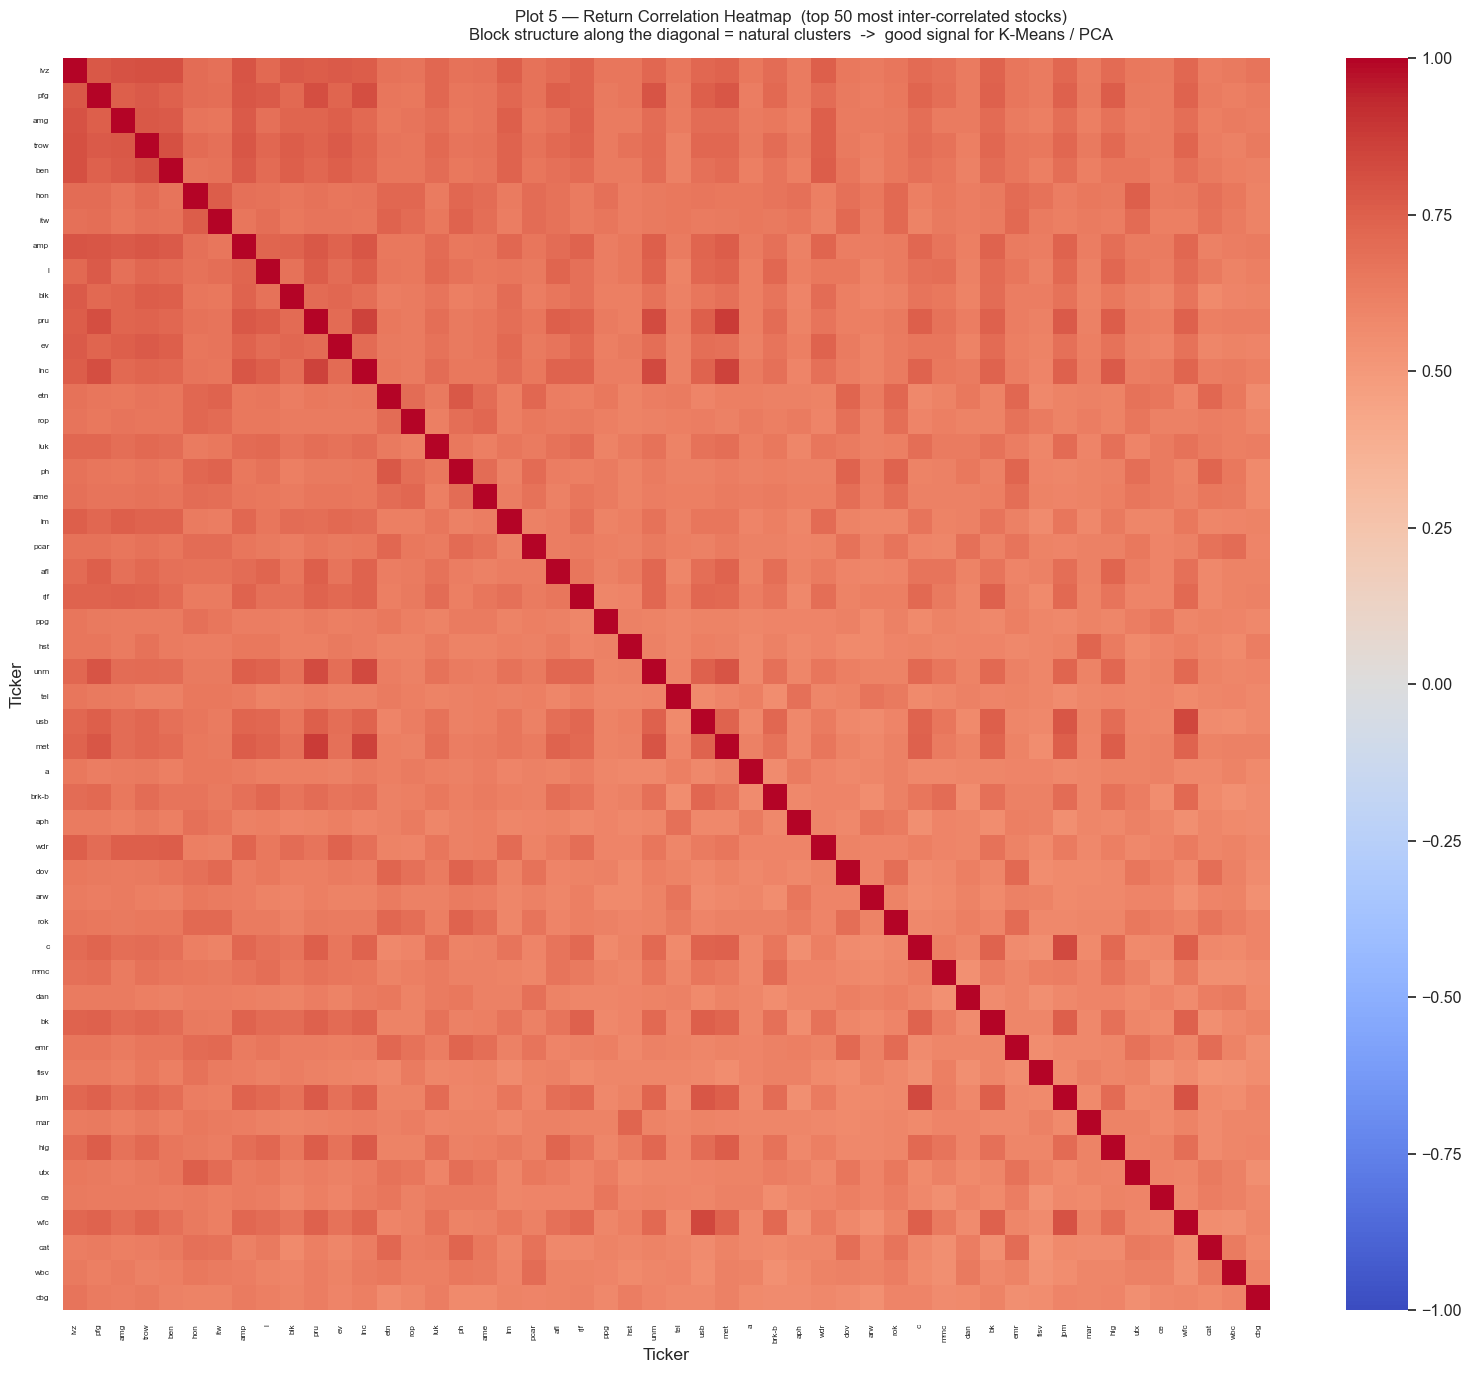

In [7]:
mean_abs_corr = corr_matrix.abs().mean().sort_values(ascending=False)
top50_tickers = mean_abs_corr.head(50).index.tolist()
corr_top50    = corr_matrix.loc[top50_tickers, top50_tickers]

fig, ax = plt.subplots(figsize=(16, 14))
fig.suptitle(
    'Plot 5 — Return Correlation Heatmap  (top 50 most inter-correlated stocks)\n'
    'Block structure along the diagonal = natural clusters  ->  good signal for K-Means / PCA',
    fontsize=12
)

sns.heatmap(
    corr_top50,
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    xticklabels=corr_top50.columns,
    yticklabels=corr_top50.columns,
    linewidths=0.0,
    ax=ax
)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=6, rotation=90)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)

plt.tight_layout()


---
## ADF Stationarity Check (after cleaning)

In [8]:
close_pivot    = all_stocks.pivot_table(index='Date', columns='Ticker', values='Close')
sample_tickers = list(pivot_filtered.dropna(axis=1).columns[:30])

results = []
for ticker in sample_tickers:
    row = {'Ticker': ticker}

    # Price level ADF
    if ticker in close_pivot.columns:
        prices = close_pivot[ticker].dropna()
        if len(prices) > 30:
            p_val = adfuller(prices, autolag='AIC')[1]
            row['price_adf_pval']   = round(p_val, 4)
            row['price_stationary'] = p_val < 0.05

    # Return ADF
    if ticker in pivot_filtered.columns:
        rets = pivot_filtered[ticker].dropna()
        if len(rets) > 30:
            p_val = adfuller(rets, autolag='AIC')[1]
            row['return_adf_pval']   = round(p_val, 4)
            row['return_stationary'] = p_val < 0.05

    results.append(row)

adf_df = pd.DataFrame(results)
print('ADF results (sample of 30 tickers):')
display(adf_df)

price_stat  = int(adf_df.get('price_stationary',  pd.Series(dtype=bool)).sum())
return_stat = int(adf_df.get('return_stationary', pd.Series(dtype=bool)).sum())
print(f'\nPrices  stationary (p<0.05): {price_stat} / {len(adf_df)}')
print(f'Returns stationary (p<0.05): {return_stat} / {len(adf_df)}')
print('\nExpected: prices NOT stationary, returns stationary.')

ADF results (sample of 30 tickers):


,Ticker,price_adf_pval,price_stationary,return_adf_pval,return_stationary
0,a,0.9908,False,0.0,True
1,aa,0.6192,False,0.0,True
2,aaba,0.9943,False,0.0,True
3,aapl,0.9863,False,0.0,True
4,abc,0.6215,False,0.0,True
5,abev,0.1411,False,0.0,True
6,abt,0.9605,False,0.0,True
7,abx,0.7336,False,0.0,True
8,adbe,1.0000,False,0.0,True
9,adi,0.9899,False,0.0,True



Prices  stationary (p<0.05): 1 / 30
Returns stationary (p<0.05): 30 / 30

Expected: prices NOT stationary, returns stationary.


---
## Plot 5 — Return ACF

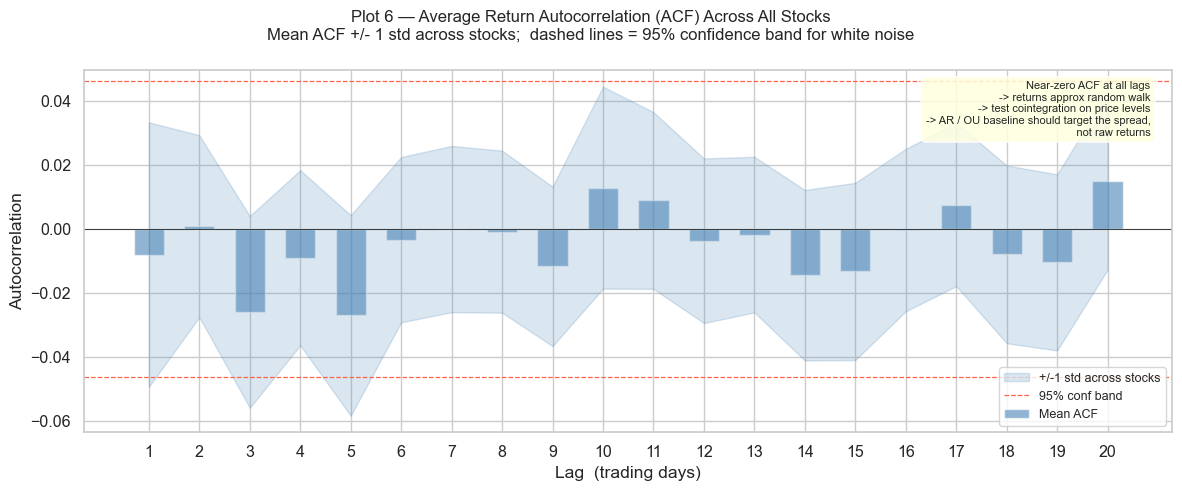

In [9]:
acf_results = []
for ticker in pivot_filtered.columns:
    series = pivot_filtered[ticker].dropna()
    if len(series) < MAX_LAGS + 10:
        continue
    try:
        vals = sm_acf(series, nlags=MAX_LAGS, fft=True)
        acf_results.append(vals)
    except Exception:
        pass

acf_matrix = np.array(acf_results)
mean_acf   = np.nanmean(acf_matrix, axis=0)
std_acf    = np.nanstd(acf_matrix,  axis=0)

avg_T  = pivot_filtered.notna().sum().mean()
conf95 = 1.96 / np.sqrt(avg_T)
lags   = np.arange(1, MAX_LAGS + 1)

fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle(
    'Plot 6 — Average Return Autocorrelation (ACF) Across All Stocks\n'
    'Mean ACF +/- 1 std across stocks;  dashed lines = 95% confidence band for white noise',
    fontsize=12
)

ax.bar(lags, mean_acf[1:], color='steelblue', alpha=0.6, width=0.6, label='Mean ACF')
ax.fill_between(
    lags,
    mean_acf[1:] - std_acf[1:],
    mean_acf[1:] + std_acf[1:],
    alpha=0.2, color='steelblue', label='+/-1 std across stocks'
)
ax.axhline( conf95, color='tomato', linewidth=0.9, linestyle='--', label='95% conf band')
ax.axhline(-conf95, color='tomato', linewidth=0.9, linestyle='--')
ax.axhline(0, color='black', linewidth=0.5)

ax.set_xlabel('Lag  (trading days)')
ax.set_ylabel('Autocorrelation')
ax.set_xticks(lags)
ax.legend(fontsize=9)
ax.text(
    0.98, 0.97,
    'Near-zero ACF at all lags\n'
    '-> returns approx random walk\n'
    '-> test cointegration on price levels\n'
    '-> AR / OU baseline should target the spread,\n'
    '   not raw returns',
    transform=ax.transAxes, fontsize=8, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', alpha=0.85)
)

plt.tight_layout()


---
## Summary

| Plot | Before cleaning | After cleaning |
|------|----------------|----------------|
| 1. Return distribution (in eda_2) | Skewness ~848, kurtosis ~765k, max 99x | Not much change to the skewness and kurtosis |
| 2. Volatility regimes (in eda_1) | May contain spurious spikes | Only genuine 2010-2017 regime events remain |
| 3. Pairwise correlation (in eda_2) | May be distorted by bad price entries | Correlations reflect true relationships |
| 4. Correlation heatmap (in eda_2) | Block structure may be noisy | Cleaner block structure (albeit not much change) |
| 5. Return ACF (in eda_2) | Near-zero at all lags | No change (does not depend on existence of outliers) |
| ADF (in eda_2) | Returns stationary | Returns stationary (confirmed) |
